# Tutorial

Load some test data

In [1]:
import numpy as np

In [2]:
labeled_grid = np.load("../data/test.npy")

Labels:
- -1 corresponds to background
- values > 0 are unique labels (that can be named later on)

In [12]:
np.unique(labeled_grid)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24, 25], dtype=int8)

## Analysis

Initialize analysis

In [4]:
from subdomain import SubDomain

# generate labels for the 'categories'
max_label = labeled_grid.max()
labels = [f"Label{i + 1}" for i in range(max_label + 1)]

my_analysis = SubDomain(labeled_grid, labels=labels)

Calculate the neighborhoods by 
- by binning the data
- calculating the neighborhood composition by aggregating the neighbors per bin

Multiple aggregation exist; a box kernel (square neighborhood), a circular neighborhood, or a Gaussian-weighted neighborhood.

In [5]:
my_analysis.calculate_neighborhoods(20, 4, neighborhood="gaussian", sigma=2)

Next, we cluster the neighborhoods using either
- _k_-means
- Gaussian Mixture Models (GMM)

In [6]:
my_analysis.cluster_neighborhoods(10, "gmm")

We can also calculate the neighborhood composition per domain using [subdomain.SubDomain.identify_domains][]

In [7]:
my_analysis.domain_neighborhoods()

label,Label1,Label2,Label3,Label4,Label5,Label6,Label7,Label8,Label9,Label10,...,Label17,Label18,Label19,Label20,Label21,Label22,Label23,Label24,Label25,Label26
domain,,,,,,,,,,,,,,,,,,,,,
0,0.001624,0.065288,0.080585,0.032000,0.081279,0.018805,0.048605,0.033070,0.016263,0.129040,...,0.026330,0.047621,0.026373,0.014849,0.046480,0.024611,0.038204,0.018816,0.041110,0.041122
1,0.012657,0.052411,0.072298,0.021331,0.077497,0.018372,0.033779,0.026296,0.052749,0.095195,...,0.023371,0.033507,0.028430,0.038381,0.045500,0.028812,0.021597,0.037075,0.053157,0.055448
2,0.003359,0.068107,0.074232,0.023434,0.044248,0.021461,0.036332,0.061972,0.017276,0.114444,...,0.019528,0.033728,0.024502,0.010430,0.058309,0.025296,0.054180,0.019729,0.064514,0.018602
3,0.011150,0.057753,0.080759,0.053148,0.076515,0.019053,0.062603,0.023532,0.024282,0.063858,...,0.036084,0.053840,0.029923,0.016450,0.051570,0.022279,0.030938,0.022119,0.047639,0.036553
4,0.003673,0.057070,0.080949,0.042781,0.065570,0.016284,0.041995,0.030810,0.014708,0.073270,...,0.066498,0.090890,0.025439,0.012175,0.042116,0.019180,0.035850,0.012677,0.051573,0.014765
5,0.002031,0.044589,0.076663,0.071872,0.103237,0.015885,0.090847,0.025130,0.012052,0.063133,...,0.039378,0.057717,0.026132,0.020005,0.043232,0.016410,0.030346,0.015004,0.043592,0.012658
6,0.026367,0.078345,0.061955,0.030577,0.063722,0.029547,0.040529,0.023593,0.041371,0.112597,...,0.022208,0.040046,0.025232,0.020854,0.040751,0.024288,0.033765,0.023404,0.032950,0.098800
7,0.002285,0.049217,0.061154,0.040488,0.066936,0.016912,0.060051,0.030216,0.012240,0.054422,...,0.050874,0.059475,0.040841,0.012291,0.045739,0.017270,0.019287,0.020274,0.035156,0.012764
8,0.009198,0.081101,0.077618,0.024898,0.045169,0.020570,0.033011,0.034285,0.021205,0.123622,...,0.020682,0.044443,0.024559,0.021055,0.049621,0.030381,0.077404,0.018744,0.060662,0.046249


In [8]:
my_analysis.domain_composition()

label,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
domain,,,,,,,,,,,,,,,,,,,,,
0,0.000038,0.078755,0.087857,0.029209,0.090168,0.016315,0.043005,0.028006,0.015916,0.167429,...,0.020060,0.036116,0.025010,0.017782,0.044951,0.025794,0.045310,0.019840,0.034631,0.036945
1,0.007109,0.042191,0.046925,0.013724,0.050728,0.030186,0.036552,0.036713,0.064393,0.122070,...,0.016302,0.012238,0.041783,0.066331,0.057793,0.041681,0.028758,0.027068,0.040311,0.097988
2,0.000580,0.097164,0.078964,0.016853,0.041356,0.015815,0.025490,0.059007,0.020175,0.162090,...,0.009075,0.022869,0.017619,0.010001,0.062022,0.018824,0.074410,0.018346,0.071263,0.012047
3,0.006150,0.086911,0.124547,0.058332,0.095323,0.012409,0.064157,0.013131,0.035982,0.066896,...,0.019841,0.044481,0.023131,0.020541,0.055055,0.020052,0.032204,0.021145,0.039973,0.044268
4,0.001115,0.078874,0.128774,0.036863,0.065853,0.009573,0.028191,0.018193,0.016997,0.078960,...,0.054498,0.152524,0.016005,0.013438,0.034362,0.013205,0.040201,0.009349,0.049832,0.008873
5,0.000251,0.051199,0.122248,0.096413,0.164041,0.007873,0.157941,0.010940,0.009520,0.052987,...,0.018777,0.042607,0.015093,0.021663,0.035918,0.009597,0.026665,0.010200,0.032172,0.006686
6,0.022404,0.105759,0.060104,0.023730,0.064653,0.021449,0.032687,0.012835,0.059045,0.132350,...,0.011065,0.025618,0.017940,0.025940,0.038136,0.021090,0.034141,0.022418,0.021181,0.166194
7,0.000435,0.065841,0.086445,0.033251,0.076353,0.010582,0.062482,0.017602,0.014012,0.051073,...,0.034808,0.054301,0.037613,0.014735,0.045473,0.013635,0.017377,0.018137,0.027684,0.007904
8,0.004490,0.117074,0.089714,0.017754,0.037720,0.013390,0.019398,0.019794,0.024475,0.165792,...,0.008867,0.033971,0.016987,0.028579,0.047329,0.025418,0.131023,0.015904,0.062249,0.041644


## Plotting

We can plot the neighborhood composition

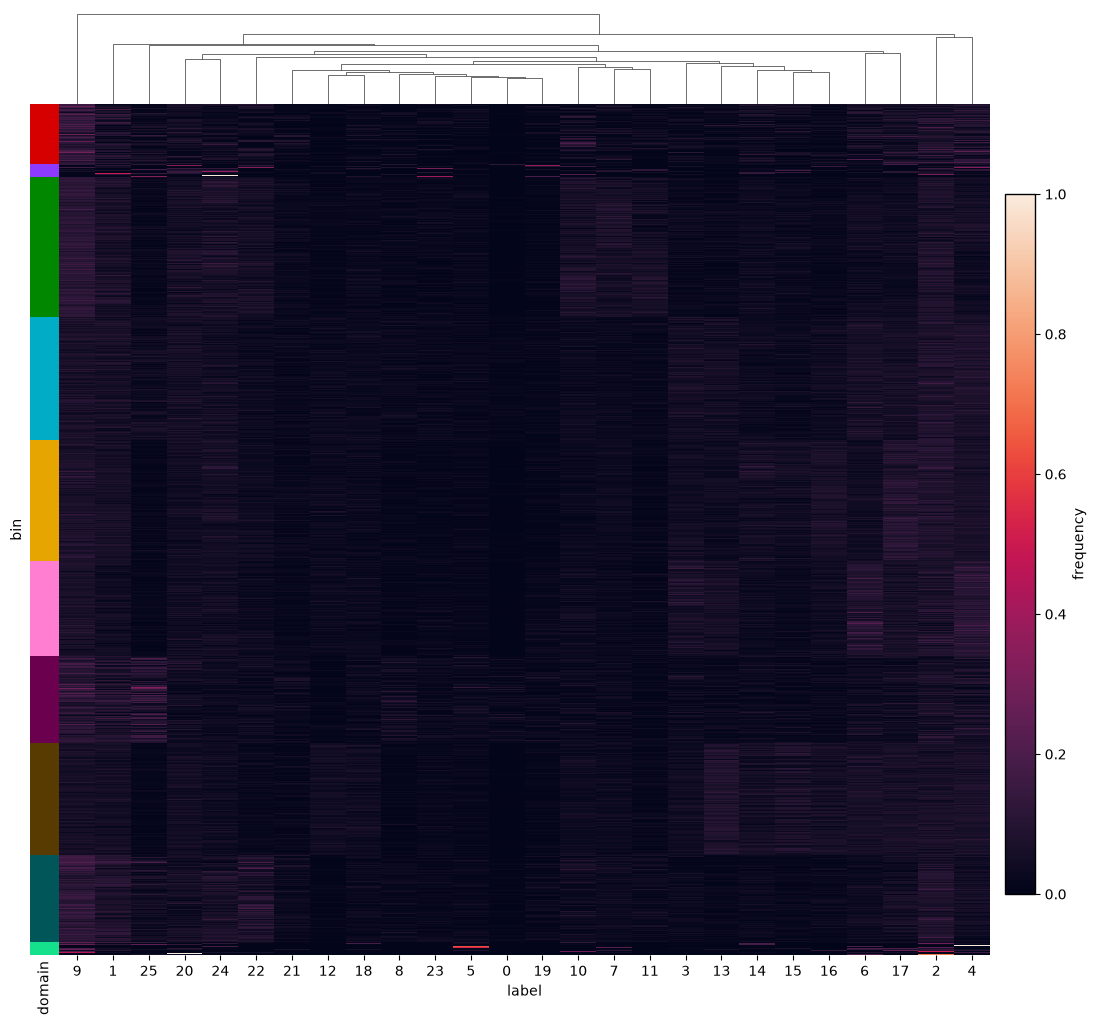

In [9]:
fig = my_analysis.plot_neighborhood_heatmap()

... and the domains

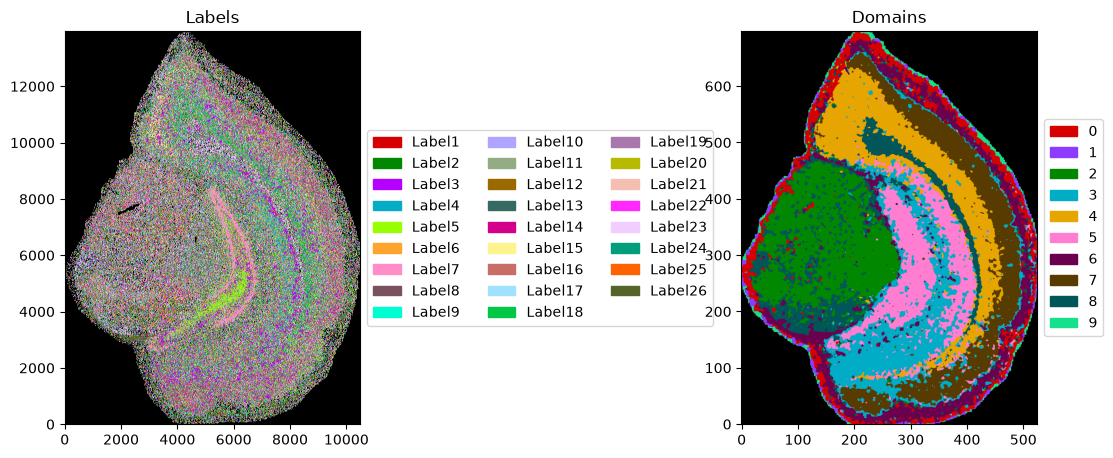

In [10]:
fig = my_analysis.plot_domains()